# Validation finale et comparaison des modèles DPE / Conso

Ce notebook a pour objectif de **valider la cohérence et la performance** des trois modèles finaux développés dans le projet :

1. **Modèle DPE sans consommation**  
   → Prédit la classe énergétique (*étiquette DPE*) uniquement à partir des caractéristiques du logement.

2. **Modèle de consommation énergétique**  
   → Estime la consommation en kWh/m²/an à partir des variables structurelles et d’isolation.

3. **Modèle DPE avec consommation**  
   → Prédit la classe DPE en tenant compte de la consommation réelle ou prédite.

L’objectif est de :
- évaluer la **chaîne de prédiction complète** (logement → conso → DPE),  
- comparer les performances entre trois scénarios :
  - **Sans consommation renseignée**,  
  - **Avec consommation renseignée**,  
  - **Via consommation prédite**.

Ce test permet de **simuler le comportement final de l’application Streamlit**, où la consommation peut être saisie par l’utilisateur ou estimée automatiquement.


### 01. Imports & configuration

In [8]:
# Imports de base
import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Réglages d’affichage
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### 02. Chargement des modèles compressés + mesure du temps

In [9]:
models_path = "../models/Compressed/"
model_files = {
    "DPE sans conso": "rf_dpe_sans_conso_compressed.joblib",
    "DPE avec conso": "rf_dpe_avec_conso_compressed.joblib",
    "Modèle conso": "rf_conso_final_compressed.joblib"
}

loaded_models = {}
load_times = {}

print("Chargement des modèles compressés...\n")
for name, filename in model_files.items():
    start = time.time()
    model = joblib.load(models_path + filename)
    elapsed = time.time() - start
    loaded_models[name] = model
    load_times[name] = elapsed
    print(f"{name:<25} chargé en {elapsed:.2f} sec")

# Résumé
pd.DataFrame(load_times.items(), columns=["Modèle", "Temps de chargement (s)"])

Chargement des modèles compressés...

DPE sans conso            chargé en 74.62 sec
DPE avec conso            chargé en 22.57 sec
Modèle conso              chargé en 62.19 sec


,Modèle,Temps de chargement (s)
0,DPE sans conso,74.621898
1,DPE avec conso,22.571804
2,Modèle conso,62.185228


### 03. Chargement du jeu de test réduit

In [10]:
# Charger le dataset complet
df = pd.read_csv("../data/Prepared/prepared_dpe_regroupe_final.csv")

# Sélectionner un petit échantillon représentatif (100 échantillons)
df_sample = df.sample(100, random_state=42).reset_index(drop=True)

print("Échantillon de test :")
df_sample[["etiquette_dpe_regroupee", "conso_m2"] + [c for c in df_sample.columns if "volume" in c or "anciennete" in c]].head()

Échantillon de test :


,etiquette_dpe_regroupee,conso_m2,anciennete,volume_logement
0,C,114.747164,45.0,154.25
1,C,187.473913,45.0,55.20
2,E,315.932692,28.0,52.00
3,A_B,82.916905,0.0,174.50
4,C,203.951327,45.0,56.50


### 04.  Comparaison des 3 scénarios de prédiction

In [11]:
rf_dpe_sans = loaded_models["DPE sans conso"]
rf_dpe_avec = loaded_models["DPE avec conso"]
rf_conso = loaded_models["Modèle conso"]

results = []

for i, row in df_sample.iterrows():
    logement = pd.DataFrame([row.drop("etiquette_dpe_regroupee")])

    # DPE sans conso
    logement_sans_conso = logement.drop(columns=["conso_m2"])
    y_pred_sans = rf_dpe_sans.predict(logement_sans_conso)[0]

    # DPE avec conso renseignée
    y_pred_avec = rf_dpe_avec.predict(logement)[0]

    # DPE avec conso prédite (chaînage)
    logement_for_conso = logement_sans_conso.copy()
    conso_pred_log = rf_conso.predict(logement_for_conso)
    conso_pred = np.expm1(conso_pred_log)
    logement_for_conso["conso_m2"] = conso_pred
    y_pred_chaine = rf_dpe_avec.predict(logement_for_conso)[0]

    results.append({
        "Réel DPE": row["etiquette_dpe_regroupee"],
        "Conso réelle": round(row["conso_m2"], 1),
        "Conso prédite": round(conso_pred[0], 1),
        "DPE sans conso": y_pred_sans,
        "DPE avec conso (renseignée)": y_pred_avec,
        "DPE via conso prédite": y_pred_chaine
    })

df_results = pd.DataFrame(results)
display(df_results)


,Réel DPE,Conso réelle,Conso prédite,DPE sans conso,DPE avec conso (renseignée),DPE via conso prédite
0,C,114.7,125.6,C,C,C
1,C,187.5,229.4,C,C,D
2,E,315.9,246.6,D,E,D
3,A_B,82.9,71.8,A_B,A_B,A_B
4,C,204.0,237.3,F_G,C,D
...,...,...,...,...,...,...
95,A_B,76.8,87.8,A_B,A_B,A_B
96,D,211.4,114.2,D,D,C
97,E,268.1,296.6,E,E,E
98,D,162.1,191.2,D,D,D


### 05. Calcul de la précision globale

In [12]:
acc_sans = accuracy_score(df_results["Réel DPE"], df_results["DPE sans conso"])
acc_avec = accuracy_score(df_results["Réel DPE"], df_results["DPE avec conso (renseignée)"])
acc_chaine = accuracy_score(df_results["Réel DPE"], df_results["DPE via conso prédite"])

print(f"\tAccuracy (Sans conso)        : {acc_sans:.3f}")
print(f"\tAccuracy (Avec conso)        : {acc_avec:.3f}")
print(f"\tAccuracy (Via conso prédite) : {acc_chaine:.3f}")

	Accuracy (Sans conso)        : 0.790
	Accuracy (Avec conso)        : 0.990
	Accuracy (Via conso prédite) : 0.670


### 06. Visualisation comparative

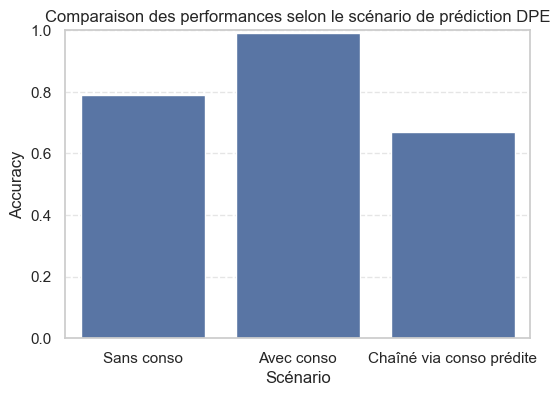

In [13]:
acc_df = pd.DataFrame({
    "Scénario": ["Sans conso", "Avec conso", "Chaîné via conso prédite"],
    "Accuracy": [acc_sans, acc_avec, acc_chaine]
})

plt.figure(figsize=(6,4))
sns.barplot(x="Scénario", y="Accuracy", data=acc_df)
plt.title("Comparaison des performances selon le scénario de prédiction DPE")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Interprétation des résultats

Les trois scénarios de prédiction montrent des comportements cohérents :

| Scénario | Accuracy | Interprétation |
|-----------|-----------|----------------|
| **Sans conso** | 0.79 | Le modèle se base uniquement sur les caractéristiques du logement et de l’isolation. Il atteint une bonne précision, mais reste limité sans l’information énergétique. |
| **Avec conso renseignée** | 0.99 | C’est la meilleure performance : la consommation réelle est un indicateur très explicatif du DPE, ce qui confirme la robustesse du modèle lorsque cette donnée est disponible. |
| **Chaîné via conso prédite** | 0.67 | La précision diminue logiquement : les erreurs du modèle de consommation se propagent dans la prédiction du DPE. Toutefois, le résultat reste cohérent et exploitable pour des logements sans DPE connu. |

### Conclusion
- Le **modèle DPE avec consommation** est le plus performant lorsqu’une donnée de consommation réelle est disponible.  
- Le **modèle enchaîné (Conso → DPE)** reste utile dans un contexte prédictif complet sans information utilisateur, au prix d’une légère perte de précision.  
- Ce benchmark valide donc la **logique à deux étages** du projet :
  - `Caractéristiques → Consommation → Étiquette DPE`

Ces résultats serviront à configurer le comportement de l’API FastAPI :
- si l’utilisateur **renseigne la consommation**, on utilise directement le modèle DPE avec conso,  
- sinon, on **prévoit la conso via le modèle 2**, puis on estime le DPE final automatiquement.
